Script Overview:
1. Tokenizes text and finds uncertainty words
2. Performs paired t test (Values for NL_Gen taken manually from NL_Gen_H3 script and inputted)
3. Plots type of uncertainty terms

1. Tokenizes text and finds uncertainty words

In [ ]:
import spacy 
from sklearn.feature_extraction.text import CountVectorizer


nlp = spacy.load("nl_core_news_sm")
excluded_tokens = set()
def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[3:] # line four is where the text starts 
        text = "".join(lines)
    
    nlp.max_length = max(len(text), 2000000)
    doc = nlp(text)
    return(doc)
    


In [1]:
import spacy 
nlp = spacy.load("nl_core_news_sm")
uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])

def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[3:] # line four is where the text starts 
        text = "".join(lines)
    
    nlp.max_length = max(len(text), 2000000)
    doc = nlp(text)
    return doc

def find_terms(doc_tokens):
    found_terms = []
    for token in doc_tokens:
        if token.text.lower() in uncertainty_terms:
            found_terms.append(token.text)
    return found_terms


In [2]:
import os
doc_u_counts = []
filenames = []
years = []

for folder in os.scandir():
    if folder.is_dir():
        folder = folder.name
        for file in os.listdir(folder):
            file_path = os.path.join(f"{folder}/{file}")
            doc = tokenize_text(file_path)
            terms = find_terms(doc)
            if terms:
                doc_u_counts.append(len(terms))
                filenames.append(file)
                years.append(folder)
        
    else:
        print('This is not a directory')



This is not a directory
This is not a directory


In [3]:
import pandas as pd
df =pd.DataFrame({"Filenames" : filenames,
"Uncertainty Counts" : doc_u_counts,
"Years" : years
})

In [ ]:
# group by year 
df_by_year_file_counts = df.groupby("Years")["Filenames"].count().reset_index()
#df_by_year_file_counts
df_by_year_u_counts = df.groupby("Years")["Uncertainty Counts"].sum().reset_index()
#df_by_year_u_counts
df_group_by_year = pd.merge(df_by_year_file_counts, df_by_year_u_counts, how = "inner")
df_group_by_year["Relative Freq"] = df_group_by_year["Uncertainty Counts"]/df_group_by_year["Filenames"]
df_group_by_year

2. Performs paired t test (Values for NL_Gen taken manually from NL_Gen_H3 script and inputted)

(0.953622579574585, 0.7625143527984619)

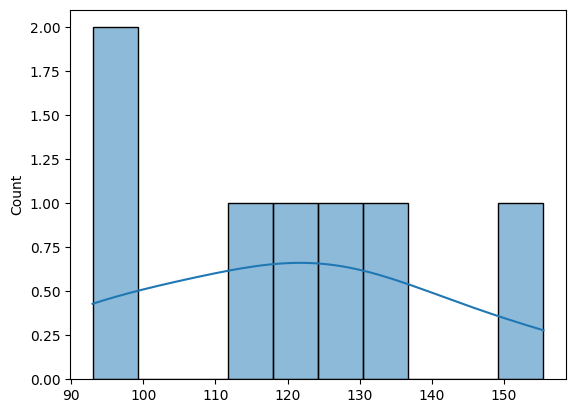

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Long = df_group_by_year["Relative Freq"]
short = [3.117647, 3.393316, 2.888641, 3.086747, 2.918317, 2.910448, 3.074675]

diff = np.array(Long) - np.array(short)
sns.histplot(diff, kde = True, bins = 10)

stat, p = shapiro(diff)
stat, p

In [33]:
# p value met so we perform a paired t test 
from scipy import stats

t_test, p = stats.ttest_rel(Long, short)
t_test, p

(14.48567145408734, 6.7845373409148205e-06)

3. Plots type of uncertainty terms

In [1]:
# for this we will use Counter
import os
import pandas as pd
import spacy
from collections import Counter 
nlp = spacy.load("nl_core_news_sm")


uncertainty_terms = set([
    "altijd", "kans", "meestal", "misschien", "mogelijk", "nooit", "onmogelijk", "onwaarschijnlijk", "onzeker", 
    "soms", "twijfelachtig", "vaak", "vermoedelijk","waarschijnlijk", "zeker", "zelden", "bijna"
])

def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[3:] # line four is where the text starts 
        text = "".join(lines)

    nlp.max_length = max(len(text), 2000000)
    doc = nlp(text)
    return(doc)


def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms
    
doc_u_counts = Counter()
found_terms = []
years = []

for folder in os.scandir():
    if folder.is_dir():
        folder = folder.name
        for file in os.listdir(folder):
            file_path = os.path.join(f"{folder}/{file}")
            doc = tokenize_text(file_path)
            terms = find_uncertainty_terms(doc)
            doc_u_counts.update(terms)
        
    else:
        print('This is not a directory')

This is not a directory
This is not a directory


In [2]:

df = pd.DataFrame(dict(words = doc_u_counts.keys(), freq = doc_u_counts.values()))
df_sorted = df.sort_values("freq", ascending= False)

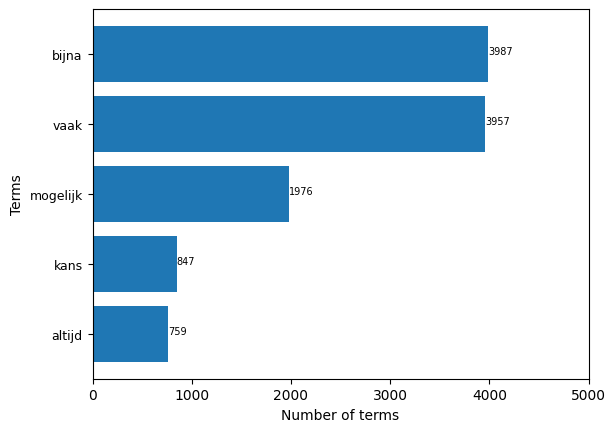

In [7]:
import matplotlib.pyplot as plt
y = list(doc_u_counts.values())
x = list(doc_u_counts.keys())

import matplotlib.pyplot as plt
def addlabels(df_sorted):
    for i in range(len(df_sorted)):
        plt.text(df_sorted.iloc[i]["freq"] + 0.1,i, str(df_sorted.iloc[i]["freq"]), fontsize = 7)


df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
df_sorted = df_sorted.tail(5)
plt.barh(df_sorted["words"] ,df_sorted["freq"])
addlabels(df_sorted)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 9)
plt.xlim(0,5000)
plt.show()